# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Dewi Wati
- **Email:** CDCC351D6X1980@student.devacademy.id
- **ID Dicoding:** CDCC351D6X1980

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh musim (season) dan kondisi cuaca (weathersit) terhadap jumlah total peminjaman sepeda?
- Bagaimana pola peminjaman sepeda berdasarkan jam dalam sehari, dan apakah ada perbedaan pola antara hari kerja dan hari libur?

## Import Semua Packages/Library yang Digunakan

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

## Data Wrangling

### Gathering Data

In [39]:
# Load dataset
day_df = pd.read_csv('/content/day.csv')
hour_df = pd.read_csv('/content/hour.csv')

In [40]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [41]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [42]:
print(f'day_df  : {day_df.shape[0]:,} baris × {day_df.shape[1]} kolom')
print(f'hour_df : {hour_df.shape[0]:,} baris × {hour_df.shape[1]} kolom')

day_df  : 731 baris × 16 kolom
hour_df : 17,379 baris × 17 kolom


**Insight:**
- Dataset berhasil dimuat
- `day_df` memiliki 16 kolom (tanpa kolom `hr`), sedangkan `hour_df` memiliki 17 kolom termasuk `hr`. Kolom `cnt` merupakan target variabel utama yang merepresentasikan total peminjaman sepeda.

### Assessing Data

In [43]:
print('=== INFO day_df ===')
day_df.info()
print('\n=== INFO hour_df ===')
hour_df.info()

=== INFO day_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

=== INFO hour_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1

In [44]:
print('=== Missing Values day_df ===')
print(day_df.isnull().sum())

print('\n=== Missing Values hour_df ===')
print(hour_df.isnull().sum())

=== Missing Values day_df ===
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

=== Missing Values hour_df ===
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [45]:
print('=== Duplikasi day_df  :', day_df.duplicated().sum())
print('=== Duplikasi hour_df :', hour_df.duplicated().sum())

=== Duplikasi day_df  : 0
=== Duplikasi hour_df : 0


In [46]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [47]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Tidak ada missing values pada kedua dataset.
- Tidak ada baris duplikat.
- Kolom `dteday` masih bertipe `object`, perlu dikonversi ke datetime.
- Beberapa kolom kategorikal (season, weathersit, weekday, mnth) tersimpan sebagai integer, oleh karena itu perlu di-mapping ke label deskriptif untuk kemudahan analisis.


### Cleaning Data

In [48]:
# Konversi tipe data
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Mapping label kategorikal
season_map     = {1: 'Springer', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map    = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'}
weekday_map    = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
month_map      = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                  7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
year_map       = {0: 2011, 1: 2012}

for df in [day_df, hour_df]:
    df['season_label']   = df['season'].map(season_map)
    df['weather_label']  = df['weathersit'].map(weather_map)
    df['weekday_label']  = df['weekday'].map(weekday_map)
    df['month_label']    = df['mnth'].map(month_map)
    df['year_label']     = df['yr'].map(year_map)

    # De-normalisasi variabel numerik
    df['temp_celsius']   = df['temp'] * 41
    df['hum_pct']        = df['hum'] * 100
    df['windspeed_kmh']  = df['windspeed'] * 67

day_df[['dteday','season_label','weather_label','temp_celsius','cnt']].head()

,dteday,season_label,weather_label,temp_celsius,cnt
0,2011-01-01,Springer,Mist/Cloudy,14.110847,985
1,2011-01-02,Springer,Mist/Cloudy,14.902598,801
2,2011-01-03,Springer,Clear,8.050924,1349
3,2011-01-04,Springer,Clear,8.200000,1562
4,2011-01-05,Springer,Clear,9.305237,1600


In [56]:
day_df.to_csv('main_data.csv', index=False)
hour_df.to_csv('hour_data.csv', index=False)

print('main_data.csv berhasil disimpan!')
print(f'Jumlah baris  : {day_df.shape[0]}')
print(f'Jumlah kolom  : {day_df.shape[1]}')
print(f'Kolom         : {list(day_df.columns)}')

main_data.csv berhasil disimpan!
Jumlah baris  : 731
Jumlah kolom  : 25
Kolom         : ['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt', 'season_label', 'weather_label', 'weekday_label', 'month_label', 'year_label', 'temp_celsius', 'hum_pct', 'windspeed_kmh', 'demand_cluster']


**Insight:**
- Kolom `dteday` berhasil dikonversi ke tipe datetime.
- Kolom kategorikal telah di-mapping ke label yang mudah dibaca.
- Variabel numerik (suhu, kelembapan, kecepatan angin) de-dinormalisasi ke satuan aslinya.
- Data siap untuk tahap eksplorasi dan analisis lebih lanjut.

## Exploratory Data Analysis (EDA)

### Explore ...

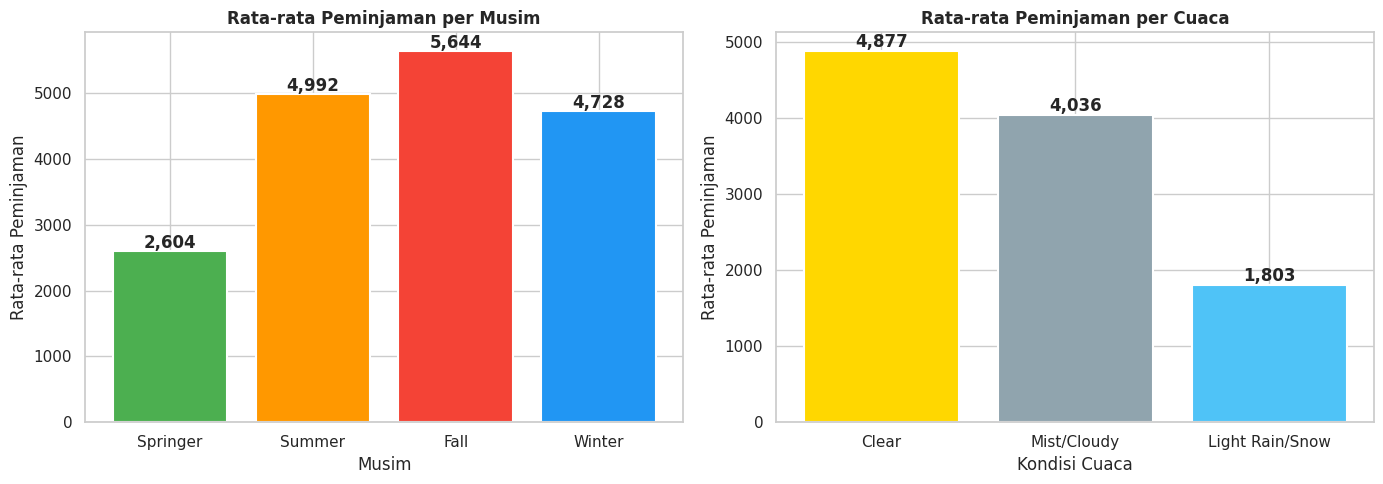

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Kiri: Peminjaman per Musim ---
season_order = ['Springer', 'Summer', 'Fall', 'Winter']
season_avg = day_df.groupby('season_label')['cnt'].mean().reindex(season_order)

axes[0].bar(season_avg.index, season_avg.values,
            color=['#4CAF50','#FF9800','#F44336','#2196F3'],
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Rata-rata Peminjaman per Musim', fontweight='bold')
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Rata-rata Peminjaman')
for i, v in enumerate(season_avg.values):
    axes[0].text(i, v + 50, f'{v:,.0f}', ha='center', fontweight='bold')

# --- Kanan: Peminjaman per Cuaca ---
weather_order = ['Clear', 'Mist/Cloudy', 'Light Rain/Snow']
weather_avg = day_df[day_df['weather_label'].isin(weather_order)] \
              .groupby('weather_label')['cnt'].mean().reindex(weather_order)

axes[1].bar(weather_avg.index, weather_avg.values,
            color=['#FFD700','#90A4AE','#4FC3F7'],
            edgecolor='white', linewidth=1.5)
axes[1].set_title('Rata-rata Peminjaman per Cuaca', fontweight='bold')
axes[1].set_xlabel('Kondisi Cuaca')
axes[1].set_ylabel('Rata-rata Peminjaman')
for i, v in enumerate(weather_avg.values):
    axes[1].text(i, v + 50, f'{v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

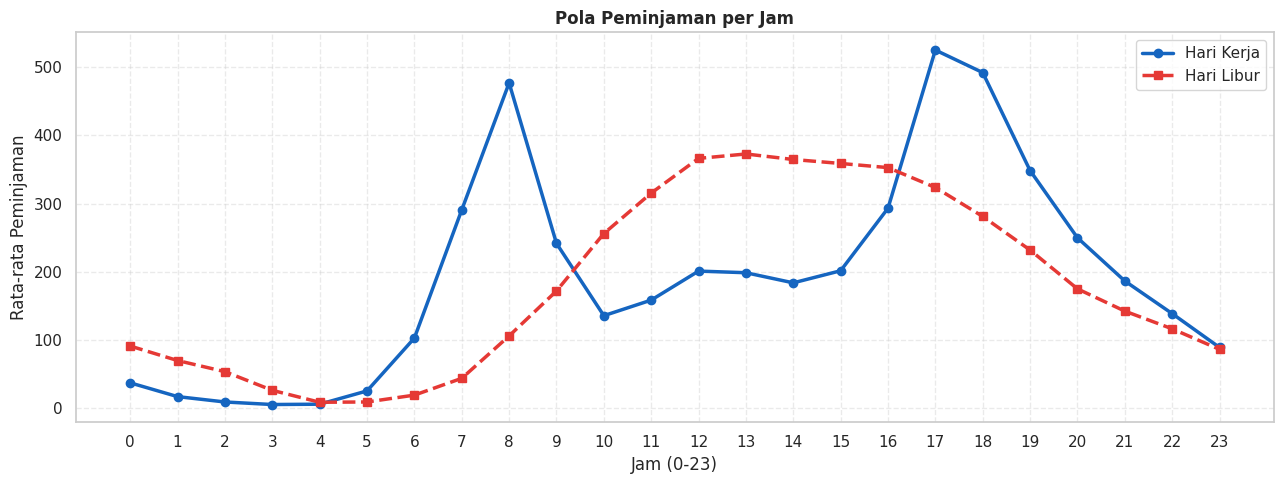

In [50]:
fig, ax = plt.subplots(figsize=(13, 5))

hourly_wd  = hour_df[hour_df['workingday']==1].groupby('hr')['cnt'].mean()
hourly_hol = hour_df[hour_df['workingday']==0].groupby('hr')['cnt'].mean()

ax.plot(hourly_wd.index, hourly_wd.values,
        marker='o', linewidth=2.5, color='#1565C0', label='Hari Kerja')
ax.plot(hourly_hol.index, hourly_hol.values,
        marker='s', linewidth=2.5, color='#E53935', label='Hari Libur', linestyle='--')

ax.set_title('Pola Peminjaman per Jam', fontweight='bold')
ax.set_xlabel('Jam (0-23)')
ax.set_ylabel('Rata-rata Peminjaman')
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

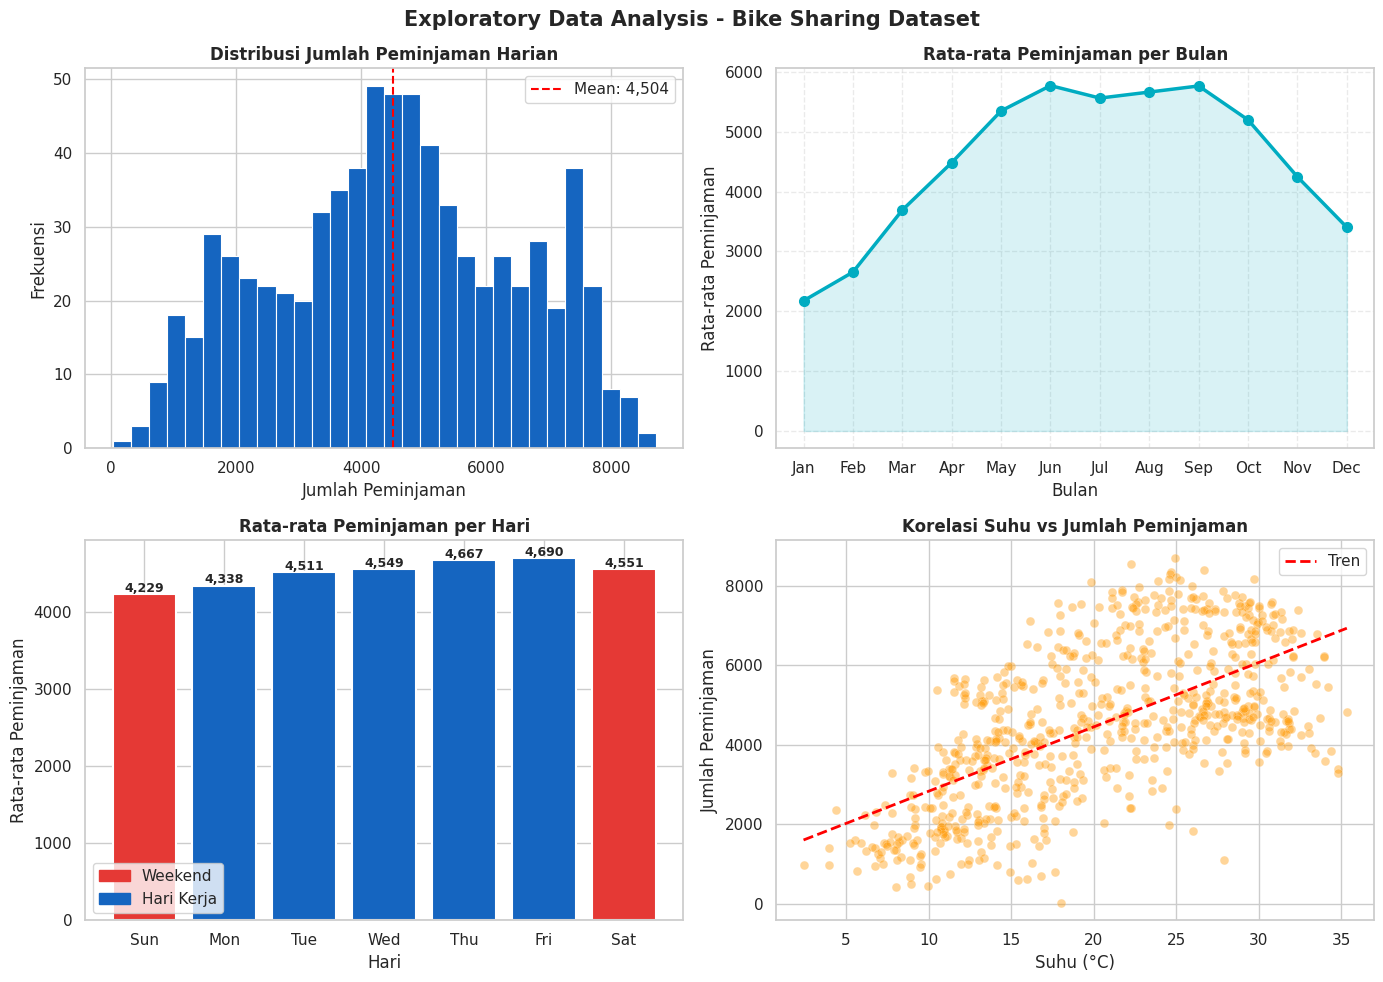

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis - Bike Sharing Dataset', fontsize=15, fontweight='bold')

# --- 1. Distribusi Total Peminjaman (cnt) ---
axes[0,0].hist(day_df['cnt'], bins=30, color='#1565C0', edgecolor='white', linewidth=0.8)
axes[0,0].set_title('Distribusi Jumlah Peminjaman Harian', fontweight='bold')
axes[0,0].set_xlabel('Jumlah Peminjaman')
axes[0,0].set_ylabel('Frekuensi')
axes[0,0].axvline(day_df['cnt'].mean(), color='red', linestyle='--', label=f"Mean: {day_df['cnt'].mean():,.0f}")
axes[0,0].legend()

# --- 2. Peminjaman per Bulan ---
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_avg = day_df.groupby('month_label')['cnt'].mean().reindex(month_order)
axes[0,1].plot(month_order, month_avg.values, marker='o', linewidth=2.5, color='#00ACC1', markersize=7)
axes[0,1].fill_between(range(12), month_avg.values, alpha=0.15, color='#00ACC1')
axes[0,1].set_title('Rata-rata Peminjaman per Bulan', fontweight='bold')
axes[0,1].set_xlabel('Bulan')
axes[0,1].set_ylabel('Rata-rata Peminjaman')
axes[0,1].set_xticks(range(12))
axes[0,1].set_xticklabels(month_order)
axes[0,1].grid(True, linestyle='--', alpha=0.4)

# --- 3. Peminjaman per Hari dalam Seminggu ---
weekday_order = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']
weekday_avg = day_df.groupby('weekday_label')['cnt'].mean().reindex(weekday_order)
colors_wd = ['#E53935' if d in ['Sun','Sat'] else '#1565C0' for d in weekday_order]
axes[1,0].bar(weekday_order, weekday_avg.values, color=colors_wd, edgecolor='white', linewidth=1.5)
axes[1,0].set_title('Rata-rata Peminjaman per Hari', fontweight='bold')
axes[1,0].set_xlabel('Hari')
axes[1,0].set_ylabel('Rata-rata Peminjaman')
for i, v in enumerate(weekday_avg.values):
    axes[1,0].text(i, v + 30, f'{v:,.0f}', ha='center', fontsize=9, fontweight='bold')
from matplotlib.patches import Patch
axes[1,0].legend(handles=[Patch(color='#E53935', label='Weekend'),
                           Patch(color='#1565C0', label='Hari Kerja')])

# --- 4. Korelasi Suhu vs Peminjaman ---
axes[1,1].scatter(day_df['temp_celsius'], day_df['cnt'],
                  alpha=0.4, color='#FF9800', edgecolor='white', linewidth=0.3, s=40)
# Garis tren
z = np.polyfit(day_df['temp_celsius'], day_df['cnt'], 1)
p = np.poly1d(z)
x_line = np.linspace(day_df['temp_celsius'].min(), day_df['temp_celsius'].max(), 100)
axes[1,1].plot(x_line, p(x_line), color='red', linewidth=2, linestyle='--', label='Tren')
axes[1,1].set_title('Korelasi Suhu vs Jumlah Peminjaman', fontweight='bold')
axes[1,1].set_xlabel('Suhu (°C)')
axes[1,1].set_ylabel('Jumlah Peminjaman')
axes[1,1].legend()

plt.tight_layout()
plt.show()

**Insight:**
- Distribusi peminjaman harian berbentuk bimodal (dua puncak),
  menunjukkan adanya dua kondisi hari yang berbeda karakteristiknya
  (hari sepi vs hari ramai).
- Peminjaman tertinggi terjadi pada bulan Juni–September (musim panas
  hingga awal gugur), dengan puncak di bulan Juli–Agustus.
- Hari kerja (Senin–Jumat) memiliki rata-rata peminjaman lebih tinggi
  dibanding weekend, mengindikasikan sepeda banyak digunakan untuk
  keperluan commuting (berangkat/pulang kerja).
- Terdapat korelasi positif antara suhu dan jumlah peminjaman, semakin
  hangat cuaca, semakin banyak orang meminjam sepeda.
- Musim Fall (Gugur) mencatat rata-rata peminjaman tertinggi (5.644/hari),
  sementara cuaca Light Rain/Snow menurunkan peminjaman hingga ~63%
  dibanding hari cerah (1.803 vs 4.877/hari).
- Pada hari kerja terdapat dua puncak tajam di jam 08.00 dan 17.00 pola commuter. Pada hari libur puncak terjadi di jam 12.00–13.00 pola rekreasi yang lebih santai.
- Jam 04.00–05.00 adalah titik peminjaman terendah di semua kategori hari.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh musim (season) dan kondisi cuaca (weathersit) terhadap jumlah total peminjaman sepeda?

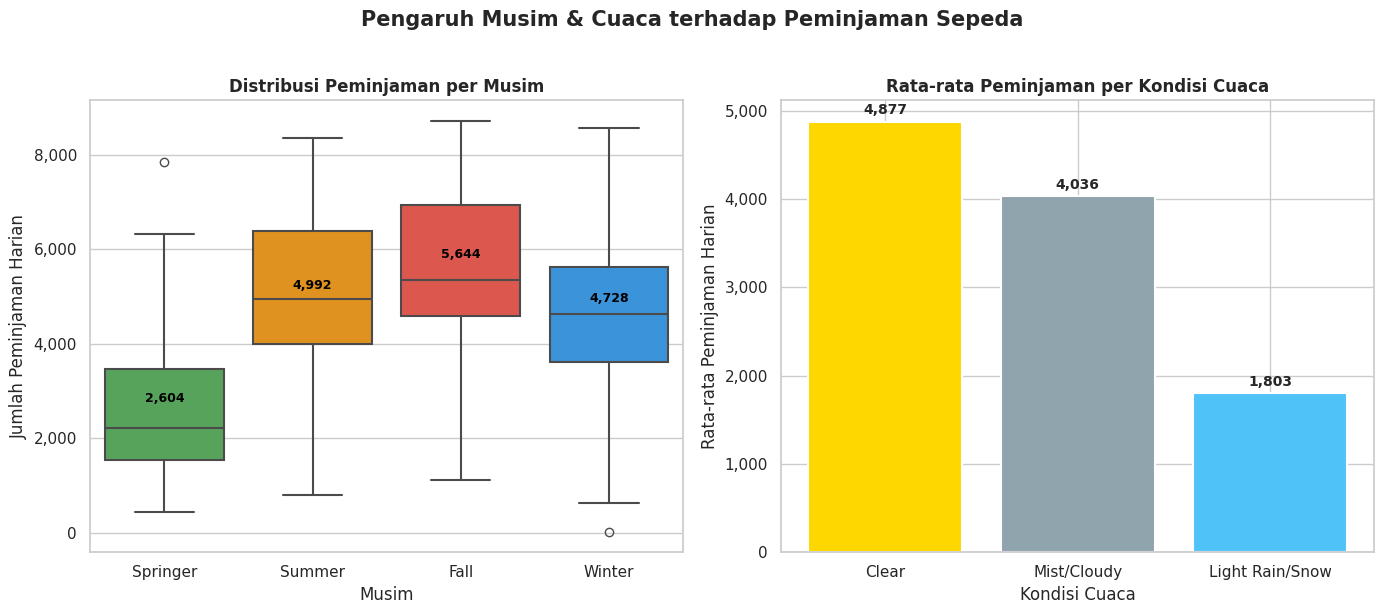

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Pengaruh Musim & Cuaca terhadap Peminjaman Sepeda', fontsize=15, fontweight='bold', y=1.02)

# Urutan musim sesuai kalender
season_order   = ['Springer', 'Summer', 'Fall', 'Winter']
season_palette = {'Springer':'#4CAF50', 'Summer':'#FF9800', 'Fall':'#F44336', 'Winter':'#2196F3'}

# Plot kiri: Boxplot musim
sns.boxplot(
    data=day_df, x='season_label', y='cnt', order=season_order,
    palette=season_palette, ax=axes[0], linewidth=1.5
)
axes[0].set_title('Distribusi Peminjaman per Musim', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Jumlah Peminjaman Harian')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# rata-rata
for i, season in enumerate(season_order):
    mean_val = day_df[day_df['season_label']==season]['cnt'].mean()
    axes[0].text(i, mean_val + 100, f'{mean_val:,.0f}', ha='center', va='bottom', fontsize=9, color='black', fontweight='bold')

# Plot kanan: Barplot cuaca
weather_order = ['Clear', 'Mist/Cloudy', 'Light Rain/Snow']
weather_data  = day_df[day_df['weather_label'].isin(weather_order)]
weather_avg   = weather_data.groupby('weather_label')['cnt'].mean().reindex(weather_order).reset_index()
weather_colors = ['#FFD700', '#90A4AE', '#4FC3F7']

bars = axes[1].bar(weather_avg['weather_label'], weather_avg['cnt'], color=weather_colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Rata-rata Peminjaman per Kondisi Cuaca', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kondisi Cuaca')
axes[1].set_ylabel('Rata-rata Peminjaman Harian')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_season_weather.png', dpi=150, bbox_inches='tight')
plt.show()

### Pertanyaan 2: Bagaimana pola peminjaman sepeda berdasarkan jam dalam sehari, dan apakah ada perbedaan pola antara hari kerja dan hari libur?

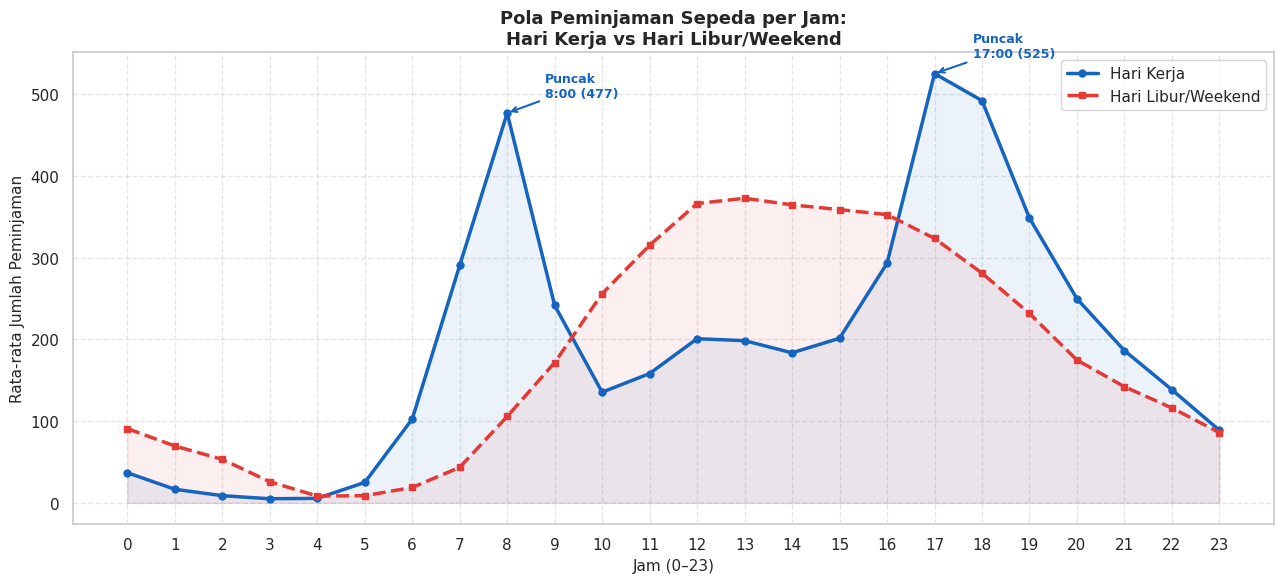

In [53]:
fig, ax = plt.subplots(figsize=(13, 6))

hourly_wd  = hour_df[hour_df['workingday']==1].groupby('hr')['cnt'].mean()
hourly_hol = hour_df[hour_df['workingday']==0].groupby('hr')['cnt'].mean()

ax.plot(hourly_wd.index,  hourly_wd.values,  marker='o', linewidth=2.5, color='#1565C0', label='Hari Kerja', markersize=5)
ax.plot(hourly_hol.index, hourly_hol.values, marker='s', linewidth=2.5, color='#E53935', label='Hari Libur/Weekend', markersize=5, linestyle='--')

# Anotasi jam puncak
for hr, val in [(8, hourly_wd[8]), (17, hourly_wd[17])]:
    ax.annotate(f'Puncak\n{hr}:00 ({val:.0f})', xy=(hr, val), xytext=(hr+0.8, val+20),
                fontsize=9, color='#1565C0', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1.5))

ax.fill_between(hourly_wd.index, hourly_wd.values, alpha=0.08, color='#1565C0')
ax.fill_between(hourly_hol.index, hourly_hol.values, alpha=0.08, color='#E53935')

ax.set_title('Pola Peminjaman Sepeda per Jam:\nHari Kerja vs Hari Libur/Weekend', fontsize=13, fontweight='bold')
ax.set_xlabel('Jam (0–23)', fontsize=11)
ax.set_ylabel('Rata-rata Jumlah Peminjaman', fontsize=11)
ax.set_xticks(range(0, 24))
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('viz_hourly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Musim **Fall (Gugur)** mencatat rata-rata peminjaman tertinggi (5.644/hari),
  diikuti Summer (4.992) dan Winter (4.728). Musim **Spring** memiliki
  rata-rata terendah (2.604/hari) hampir setengah dari musim Fall.
- Boxplot menunjukkan musim Fall memiliki distribusi yang lebih konsisten
  (box lebih sempit), artinya peminjaman stabil tinggi di musim ini.
- Musim Spring memiliki outlier ke atas (~7.800), menandakan ada beberapa
  hari di musim semi yang justru sangat ramai kemungkinan terkait event tertentu.
- Cuaca **Clear** menghasilkan rata-rata peminjaman tertinggi (4.877/hari).
  Cuaca **Light Rain/Snow** hanya 1.803/hari turun drastis ~63%
  dibanding hari cerah.
- Pada hari kerja terdapat dua puncak tajam: **jam 08.00 (477)** saat
  berangkat kerja dan **jam 17.00 (525)** saat pulang kerja pola commuter.
- Pada hari libur/weekend pola lebih landai dengan puncak tunggal di
  **jam 12.00–13.00** mencerminkan aktivitas rekreasi yang santai.
- Perbedaan pola ini membuktikan motivasi penggunaan sepeda pada hari
  kerja (transportasi) vs hari libur (rekreasi) sangat berbeda.
- Jam **04.00–05.00** adalah titik terendah di semua kategori
  operator dapat memanfaatkan waktu ini untuk maintenance armada.Sonnet 4.6

## Analisis Lanjutan (Opsional)

In [54]:
q33 = day_df['cnt'].quantile(0.33)
q66 = day_df['cnt'].quantile(0.66)

def cluster_demand(cnt):
    if cnt <= q33:
        return 'Low Demand'
    elif cnt <= q66:
        return 'Medium Demand'
    else:
        return 'High Demand'

day_df['demand_cluster'] = day_df['cnt'].apply(cluster_demand)
print(day_df['demand_cluster'].value_counts())

demand_cluster
High Demand      249
Low Demand       241
Medium Demand    241
Name: count, dtype: int64


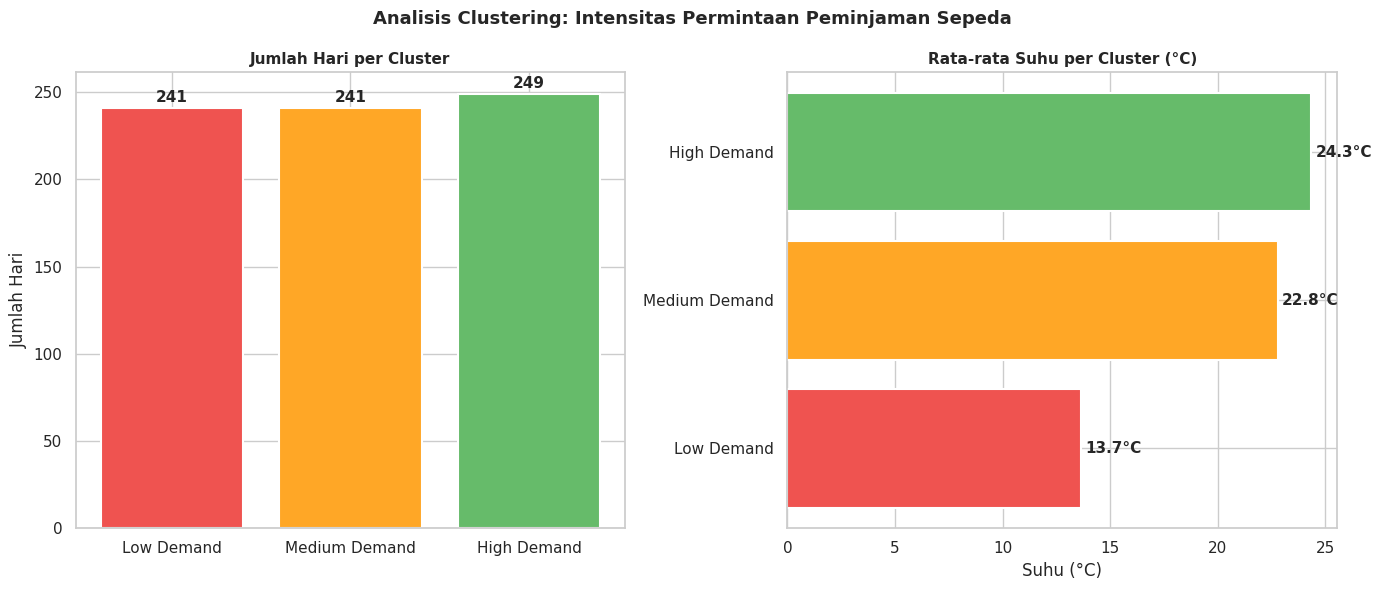

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Analisis Clustering: Intensitas Permintaan Peminjaman Sepeda', fontsize=13, fontweight='bold')

cluster_order   = ['Low Demand', 'Medium Demand', 'High Demand']
cluster_palette = {'Low Demand':'#EF5350', 'Medium Demand':'#FFA726', 'High Demand':'#66BB6A'}

# Plot kiri: Distribusi jumlah hari per cluster
cluster_counts = day_df['demand_cluster'].value_counts().reindex(cluster_order)
bars = axes[0].bar(cluster_order, cluster_counts.values, color=[cluster_palette[c] for c in cluster_order], edgecolor='white', linewidth=1.5)
axes[0].set_title('Jumlah Hari per Cluster', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Jumlah Hari')
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, str(int(bar.get_height())),
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot kanan: Rata-rata suhu per cluster
temp_by_cluster = day_df.groupby('demand_cluster')['temp_celsius'].mean().reindex(cluster_order)
axes[1].barh(cluster_order, temp_by_cluster.values, color=[cluster_palette[c] for c in cluster_order], edgecolor='white', linewidth=1.5)
axes[1].set_title('Rata-rata Suhu per Cluster (°C)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Suhu (°C)')
for i, v in enumerate(temp_by_cluster.values):
    axes[1].text(v+0.2, i, f'{v:.1f}°C', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('viz_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

- Musim **Fall (Gugur)** memiliki rata-rata peminjaman tertinggi (5.644/hari)
  dan musim **Spring (Semi)** terendah (2.604/hari) selisih lebih dari 2x lipat. Cuaca **Clear** menghasilkan peminjaman tertinggi (4.877/hari), sedangkan **Light Rain/Snow** turun drastis ~63% menjadi 1.803/hari. Operator sebaiknya memaksimalkan ketersediaan armada pada musim Fall dengan cuaca cerah, dan menyiapkan strategi diskon atau fleksibilitas saat cuaca buruk.
- Hari kerja memiliki dua puncak tajam di **jam 08.00 (477)** dan **jam 17.00 (525)**
  yang mencerminkan pola commuter, sedangkan hari libur memiliki puncak tunggal
  di **jam 12.00–13.00** yang mencerminkan pola rekreasi. Operator perlu memastikan
  sepeda tersedia maksimum di stasiun perkantoran pada jam 07.30 dan 16.30 di
  hari kerja, serta mendistribusikan sepeda ke jalur rekreasi pada hari libur.